# Leveraging Weak Learners via Adaptive Boosting (AdaBoost)

## Summary of Concepts

**Boosting** is an ensemble method designed to improve the performance of machine learning models by focusing on training examples that are difficult to classify. It achieves this by combining simple base classifiers, often called **weak learners** (e.g., decision tree stumps), which have only a slight performance advantage over random guessing.

### Key Characteristics:

* **Iterative Reweighting:** Unlike bagging, AdaBoost uses the complete training dataset in each iteration but reweights the examples. Examples that were misclassified by the previous weak learner receive higher weights, forcing the next learner to focus on them.
* **Error Minimization:** It can effectively reduce both model **bias** and **variance**. However, in practice, boosting algorithms are known for high variance and a tendency to overfit the training data if not tuned carefully.
* **The Complexity Tradeoff:** Ensemble learning significantly increases computational complexity. As noted by the famous $1 million Netflix Prize, even if an ensemble model produces superior predictive performance, the engineering effort and computational costs may make it unfeasible for real-world production environments.

---

## The AdaBoost Algorithm

The core procedure of AdaBoost can be summarized through its pseudocode and formulas. We denote element-wise multiplication by the cross symbol ($\times$) and the dot-product between two vectors by a dot symbol ($\cdot$).

1. Set the weight vector, $\mathbf{w}$, to uniform weights, where $\sum_i w_i = 1$.
2. For $j$ in $m$ boosting rounds, do the following:
* **a.** Train a weighted weak learner: $C_j = \text{train}(\mathbf{X}, \mathbf{y}, \mathbf{w})$
* **b.** Predict class labels: $\mathbf{\hat{y}} = \text{predict}(C_j, \mathbf{X})$
* **c.** Compute the weighted error rate:

$$\varepsilon = \mathbf{w} \cdot (\mathbf{\hat{y}} \neq \mathbf{y})$$


* **d.** Compute the coefficient:

$$\alpha_j = 0.5 \log \frac{1-\varepsilon}{\varepsilon}$$


* **e.** Update the weights:

$$\mathbf{w} := \mathbf{w} \times \exp(-\alpha_j \times \mathbf{\hat{y}} \times \mathbf{y})$$


* **f.** Normalize the weights to sum to 1:

$$\mathbf{w} := \frac{\mathbf{w}}{\sum_i w_i}$$




3. Compute the final prediction using a weighted majority vote:

$$\hat{y} = \left(\sum_{j=1}^m (\alpha_j \times \text{predict}(C_j, \mathbf{X})) > 0\right)$$



---

### 1. Manual Step-by-Step AdaBoost Calculation

This code manually computes the error rate ($\varepsilon$), coefficient ($\alpha_j$), and the updated weights for a single boosting round based on the toy example provided in the text.

In [18]:
import numpy as np

# True labels and predicted labels for a 10-example subset
y = np.array([1, 1, 1, -1, -1, -1, 1, 1, 1, -1])
yhat = np.array([1, 1, 1, -1, -1, -1, -1, -1, -1, -1])
correct = (y == yhat)

# Initialize uniform weights
weights = np.full(10, 0.1)
print(f'Initial weights: \n{weights}\n')

# Step 2c: Compute weighted error rate (epsilon)
epsilon = np.mean(~correct)
print(f'Epsilon: {epsilon}')

# Step 2d: Compute the coefficient (alpha_j)
alpha_j = 0.5 * np.log((1 - epsilon) / epsilon)
print(f'Alpha_j: {alpha_j}\n')

# Step 2e: Update weights based on correct/incorrect predictions
update_if_correct = 0.1 * np.exp(-alpha_j * 1 * 1)
print(f'Weight update if correct: {update_if_correct}')

update_if_wrong_1 = 0.1 * np.exp(-alpha_j * 1 * -1)
print(f'Weight update if wrong: {update_if_wrong_1}\n')

# Apply updates conditionally
weights = np.where(correct == 1, update_if_correct, update_if_wrong_1)
print(f'Updated weights before normalization: \n{weights}\n')

# Step 2f: Normalize weights
normalized_weights = weights / np.sum(weights)

Initial weights: 
[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

Epsilon: 0.3
Alpha_j: 0.42364893019360184

Weight update if correct: 0.06546536707079771
Weight update if wrong: 0.1527525231651947

Updated weights before normalization: 
[0.06546537 0.06546537 0.06546537 0.06546537 0.06546537 0.06546537
 0.15275252 0.15275252 0.15275252 0.06546537]



In [19]:
import pandas as pd

# Load dataset
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/'
                      'wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

# Drop class 1 to make it a binary classification problem
df_wine = df_wine[df_wine['Class label'] != 1]

y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=1,
                                                    stratify=y)

### 2. Setting up the AdaBoost Ensemble (Scikit-Learn)

Using a decision tree stump (`max_depth=1`) as the base estimator, we create an ensemble of 500 stumps to classify the Wine dataset.

In [20]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Base estimator: a decision tree stump
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=1)

ada = AdaBoostClassifier(estimator=tree, # Changed from base_estimator to estimator
                         n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)

# 1. Evaluate single Decision Tree Stump
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies {tree_train:.3f}/{tree_test:.3f}')

# 2. Evaluate AdaBoost Classifier
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)

ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)
print(f'AdaBoost train/test accuracies {ada_train:.3f}/{ada_test:.3f}')

Decision tree train/test accuracies 0.916/0.875
AdaBoost train/test accuracies 0.968/0.917


### 3. Plotting Decision Regions

Visualizing how AdaBoost creates a substantially more complex decision boundary than a single weak decision stump.

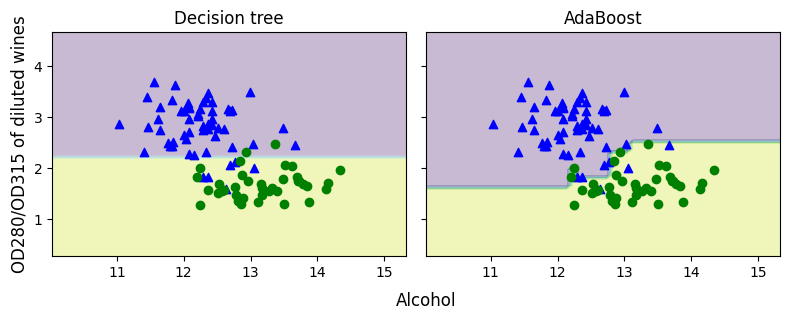

In [21]:
import matplotlib.pyplot as plt

x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(8, 3))

for idx, clf, tt in zip([0, 1],
                        [tree, ada],
                        ['Decision tree', 'AdaBoost']):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train==0, 0],
                       X_train[y_train==0, 1],
                       c='blue', marker='^')
    axarr[idx].scatter(X_train[y_train==1, 0],
                       X_train[y_train==1, 1],
                       c='green', marker='o')
    axarr[idx].set_title(tt)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)

plt.tight_layout()
plt.text(0, -0.2,
         s='Alcohol',
         ha='center',
         va='center',
         fontsize=12,
         transform=axarr[1].transAxes)

plt.show()